## Trabajo Práctico - Estadística Avanzada y Modelos de Regresión
### Análisis de propiedades de Properati
#### Grupo: Aboulafia Gerardo, Barquet Amelie, Lombardo Micaela, Vazquez Agustina
---

In [ ]:
# Imports HOLA jj
#
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import shapely.wkt
import geopandas as gpd
import geopy.distance
from shapely.geometry import Point, Polygon, MultiPolygon
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, RandomizedSearchCV
from scipy import stats
from shapely.ops import unary_union
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.api as sm

### 1. Estudio de estructura y limpieza preliminar

In [2]:
# Ruta del archivo CSV
file_name_str = "/Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 4/Estadística Avanzada/TP/properaty_dataset_alumnos.csv"

data = pd.read_csv(file_name_str)

# Mostrar información del archivo
print("Data types:"+str(data.dtypes))
print("Data shape:"+str(data.shape))

# Mostrar las primeras filas del archivo
data.head()

Data types:id                           object
start_date                   object
end_date                     object
created_on                   object
latitud                     float64
longitud                    float64
place_l2                     object
place_l3                     object
place_l4                     object
place_l5                     object
place_l6                    float64
operation                    object
property_type                object
property_rooms              float64
property_bedrooms           float64
property_surface_total      float64
property_surface_covered    float64
property_price              float64
property_currency            object
property_title               object
dtype: object
Data shape:(200000, 20)


/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021_geopandas/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3457: DtypeWarning: Columns (9) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,id,start_date,end_date,created_on,latitud,longitud,place_l2,place_l3,place_l4,place_l5,place_l6,operation,property_type,property_rooms,property_bedrooms,property_surface_total,property_surface_covered,property_price,property_currency,property_title
0,WU6sY9relATTrVzUgo6ijA==,2021-02-22,9999-12-31,2021-02-22,-34.598973,-58.429204,Capital Federal,Villa Crespo,NaN,NaN,NaN,Venta,Departamento,4.0,NaN,107.0,100.0,205000.0,USD,Departamento - Villa Crespo BIEN UBICADO
1,dmEs2Sd/6IjoJNWB0CdbJQ==,2021-12-23,2022-01-27,2021-12-23,-34.583655,-58.501788,Capital Federal,Villa Pueyrredón,NaN,NaN,NaN,Venta,Departamento,2.0,1.0,48.0,45.0,120000.0,USD,"Departamento en venta, Griveo 2746, Villa Puey..."
2,CTFPJk9houRcGjOZcxGvEA==,2021-06-30,9999-12-31,2021-06-30,-34.571827,-58.483719,Capital Federal,Villa Urquiza,NaN,NaN,NaN,Venta,Departamento,1.0,1.0,30.0,27.0,104000.0,USD,HERMOSO DEPARTAMENTO CONTRAFRENTE CON VISTA AB...
3,z6/hBM7rtl3cTg2lsm5ZSQ==,2021-10-16,2021-11-15,2021-10-16,-34.632078,-58.443757,Capital Federal,Parque Chacabuco,NaN,NaN,NaN,Venta,Departamento,3.0,2.0,88.0,84.0,148000.0,USD,DEPARTAMENTO 3 AMB C/ BALCÓN Y DEPENDENCIA · P...
4,icWo1was+O+t6NMP7GzB0Q==,2021-01-16,2021-04-08,2021-01-16,NaN,NaN,Capital Federal,Coghlan,NaN,NaN,NaN,Venta,Departamento,NaN,NaN,NaN,152.0,410404.0,USD,Departamento en Coghlan


In [3]:
# Filtrar el dataset para quedarnos con las propiedades que tienen precio en dolares y están en Capital Federal
data = data[(data['property_currency'] == 'USD') & (data['place_l2'] == 'Capital Federal')]

#filtro de depto, casa, ph
data= data[data['property_type'].isin(['Departamento', 'Casa', 'PH'])]

In [4]:
# Renombrar columnas y sacar el prefijo property
data.columns = data.columns.str.replace('property_', '')

### 2. Data cleaning

#### Estudio de valores nulos

In [5]:
# Se crea un dataframe con información de porcentajes de valores nulos, cuenta de nulos y total registros para cada uno de los campos del dataset
print('Estudio de datos faltantes:')
data_isnull = (round((data.isnull().sum() / data.shape[0])*100,2))
df_data_isnull = pd.DataFrame(data_isnull)
df_data_isnull['count_nulls'] = data.isnull().sum()
df_data_isnull['count_notnulls'] = data.notnull().sum()
df_data_isnull.rename(columns = {0: 'percent_nulls'}, inplace=True)
df_data_isnull

Estudio de datos faltantes:


,percent_nulls,count_nulls,count_notnulls
id,0.00,0,92609
start_date,0.00,0,92609
end_date,0.00,0,92609
created_on,0.00,0,92609
latitud,4.02,3725,88884
longitud,4.02,3725,88884
place_l2,0.00,0,92609
place_l3,0.43,402,92207
place_l4,95.89,88799,3810
place_l5,100.00,92609,0


In [6]:
# Eliminamos las columnas place_l5 y place_l6 ya que tienen un 100% de valores nulos. Además eliminamos la columna currency ya que tiene un solo valor, y la columna place_l4 ya que tiene 96% de valores nulos
data  = data.drop(['place_l5', 'place_l6', 'currency', 'place_l4'], axis=1)

Entendemos que hay algunas filas en las que no tienen mapeado el número de habitaciones o metros cuadrados. Sin embargo, a través de expresiones regulares podemos recuperar algunos datos que se encuentran en el título de la propiedad.

#### Imputación de valores para 'rooms'

In [7]:
#data.rename(columns={'title;;;;;': 'title'}, inplace=True)
# Función que utiliza RegEx para encontrar el número de ambientes.
def find_numbers(x_column, x_word):
    """ La función busca en la columna especificada de df la
        palabra deseada y toma el número que la precede. La idea es utilizar
        title|description como columnas y amb|dorm|hab como palabras.
    """
    fix_dict = {
        'un':'1', 'Un':'1', 'UN':'1',
        'mono':'1', 'Mono':'1', 'MONO':'1',
        'dos':'2', 'Dos':'2', 'DOS':'2',
        'tres':'3', 'Tres':'3', 'TRES':'3',
        'cuatro':'4', 'Cuatro':'4', 'CUATRO':'4',
        'cinco':'5', 'Cinco':'5', 'CINCO':'5',
        'seis':'6', 'Seis':'6', 'SEIS':'6',
        'siete':'7', 'Siete':'7', 'SIETE':'7',
        'ocho':'8', 'Ocho':'8', 'OCHO':'8',
        'nueve':'9', 'Nueve':'9', 'NUEVE':'9'
    }

    # Ajustar patrón para que busque también números y el término completo (ej. "3 ambientes")
    pattern = re.compile(r'(?i)(?P<amb>(\w+|\d+))\s*' + x_word)

    re_amb = data[x_column].apply(lambda x: pattern.search(str(x)))
    match_amb = re_amb.apply(lambda x: x.group('amb') if x else None)

    # Reemplazo de palabras por números
    match_amb.replace(fix_dict, inplace=True)
    match_amb.fillna('', inplace=True)
    mask_numeric = match_amb.apply(lambda x: x.isnumeric())
    match_amb[~mask_numeric] = np.nan
    return match_amb

# Función para llenar rooms_total
def fill_rooms_total(x_rooms_total, x_column, x_word):
    """ Llenado del totalizador 'rooms_total' con la combinación correcta de
        title|description como columnas y amb|dorm|hab como palabras.
    """
    rooms_partial = find_numbers(x_column, x_word)

    if x_word == 'ambientes':
        # Convertir directamente a números, reemplazando valores no numéricos con NaN
        rooms_partial = pd.to_numeric(rooms_partial, errors='coerce')
    else:
        # Convertir directamente a números y sumar 1, reemplazando valores no numéricos con NaN
        rooms_partial = pd.to_numeric(rooms_partial, errors='coerce') + 1

    x_rooms_total.fillna(rooms_partial, inplace=True)
    return x_rooms_total

# Inicialización del contador
rooms_total = pd.Series([np.nan for _ in data.rooms])

# Llamados con las diferentes combinaciones con la función mejorada
rooms_total = fill_rooms_total(rooms_total, 'title', 'ambientes')
rooms_total = fill_rooms_total(rooms_total, 'title', 'dorm')
rooms_total = fill_rooms_total(rooms_total, 'title', 'hab')

# Búsqueda de monoambientes
pattern_mono = re.compile('(?i)monoambiente')
re_amb_mono = data['title'].astype(str).apply(lambda x: pattern_mono.search(x))
rooms_partial_mono = re_amb_mono.apply(lambda x: 1 if x is not None else None)
rooms_total.fillna(pd.Series(rooms_partial_mono), inplace=True)

# Guardar el resultado final en el DataFrame
data['rooms_total'] = rooms_total

# Crear una nueva columna 'rooms_final' que sea igual a 'rooms'
data['rooms_final'] = data['rooms']

# Reemplazar los valores nulos en 'rooms_final' con los valores de 'rooms_total'
data['rooms_final'].fillna(data['rooms_total'], inplace=True)

# Comparamos la cantidad de nulos en 'rooms' y 'rooms_final'
print(data['rooms'].isnull().sum())
print(data['rooms_final'].isnull().sum())

1036
803


#### Imputación de valores para 'surface'

In [8]:
# Creamos un patrón para encontrar los metros cuadrados en la columna de descripción.
patron_m2 = r"(\d{2,5})(\s)?(m|mt|mts|metros)(\s)?(2)?"
patron_m2_regex = re.compile(patron_m2, re.IGNORECASE)

# Convertimos la columna 'title' a tipo string si no lo es ya.
title_series = data['title'].astype(str)

# Utilizamos una función lambda para buscar el patrón en cada título.
# Extraemos solo el número (grupo 1)
m2_totales = title_series.apply(lambda x: patron_m2_regex.search(x))

# Extraemos los valores encontrados que no son nulos y aplicamos una función lambda para obtener el número (grupo 1).
m2_totales = m2_totales[m2_totales.notnull()].apply(lambda x: x.group(1))

# Asignamos los valores extraídos a una nueva columna 'm2_descripcion' en el DataFrame, y convertimos a tipo numérico.
data['m2_descripcion'] = m2_totales.astype(float)

# Crear una nueva columna 'm2_final' que sea igual a surface_total
data['m2_final'] = data['surface_total']

# Reemplazar los valores nulos en 'm2_final' con los valores de 'm2_descripcion'
data['m2_final'].fillna(data['m2_descripcion'], inplace=True)

# Comparamos la cantidad de nulos en 'm2_final' con la cantidad de nulos en 'surface_total'
print(f"Nulos en 'surface_total': {data['surface_total'].isnull().sum()}")
print(f"Nulos en 'm2_final': {data['m2_final'].isnull().sum()}")

Nulos en 'surface_total': 4831
Nulos en 'm2_final': 4689


#### Cálculo de features con geolocalización

A través de visualizaciones de las coordenadas de los datos, vemos que existen propiedades que no se encuentran en Capital Federal (incluso cuando dicen estarlo). Esto puede afectar severamente la precisión del modelo, ya que el objetivo es poder predecir el precio de propiedades de CABA.

![-](outside_propiedades.png)

In [9]:
# Verificamos algunos casos en donde la propiedad parece no estar en Capital Federal

# Caso ID SSbx+/6MNgxE6rIDYPA0+A==, parece estar en Neuquen
print(data.loc[data['id'] == 'SSbx+/6MNgxE6rIDYPA0+A==', 'title'].values[0])

# Caso ID oqSIUrrkBRMakJoEW/hYPg==, parece estar en Bariloche
print(data.loc[data['id'] == 'oqSIUrrkBRMakJoEW/hYPg==', 'title'].values[0])

# Caso ID gSjQVGHY35F1hIg3bZs0hQ==, parece estar en Bariloche
print(data.loc[data['id'] == 'gSjQVGHY35F1hIg3bZs0hQ==', 'title'].values[0])

# Caso ID 3TupSuGFOw7CerK8cDO5ug==, parece estar en Santa fe
print(data.loc[data['id'] == '3TupSuGFOw7CerK8cDO5ug==', 'title'].values[0])

DEPTO 2 DORM EN COMPLEJO CALLE LOS LIRIOS BARRIO ALTA BARDA
POSIBLE PERMUTA-Villa Huapi - Dina Huapi - Río Negro - APTO CREDITO
VENDO HERMOSA CASA EN BARILOCHE
VENDO CASA DUPLEX A ESTRENAR EN FRANCK


Verificamos que las propiedades que dicen estar en capital, en realidad no lo están. Ninguna de las ubicaciones corresponden a Capital. Por lo tanto, trabajaremos con un dataset de multipolígonos de la ciudad de Buenos Aires. Primero construiremos un multipolígono a partir del multipolígono de todos los barrios de capital. Luego, verificaremos si la propiedad efectivamente está en CABA o no. Generaremos momentáneamente una columna de Flag para verificar los resultados visualmente. Luego nos quedaremos solamente con las que cumplan la condición de estar en Buenos Aires.

In [10]:
# Cargar el dataset de barrios de Capital Federal
barrios = gpd.read_file('/Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 4/Estadística Avanzada/TP/barrios.csv')

# Convertir la columna WKT a geometrías
barrios['geometry'] = barrios['WKT'].apply(lambda x: shapely.wkt.loads(x))

# Crear un polígono que combine todos los polígonos de los barrios
combined_polygon = unary_union(barrios['geometry'])

In [11]:
# Verificar si las propiedades están dentro del MultiPolygon
def verificar_propiedades(data, multi_polygon):
    # Separar las filas con y sin valores válidos de latitud y longitud
    data_con_coords = data.dropna(subset=['latitud', 'longitud'])
    data_sin_coords = data[data[['latitud', 'longitud']].isna().any(axis=1)]
    
    # Verificar si los puntos están dentro del MultiPolygon
    puntos = data_con_coords.apply(lambda row: Point(row['longitud'], row['latitud']), axis=1)
    data_con_coords['en_capital'] = puntos.apply(lambda point: multi_polygon.is_valid and multi_polygon.contains(point))
    
    # Unir nuevamente los dataframes
    data_resultante = pd.concat([data_con_coords, data_sin_coords], ignore_index=True)
    return data_resultante

# Aplicar la función al dataframe de propiedades
data = verificar_propiedades(data, combined_polygon)

/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021_geopandas/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


In [12]:
# Vemos cuántas propiedades se encuentran fuera de capital
data.en_capital.value_counts()

True     88683
False      201
Name: en_capital, dtype: int64

#### Verificamos visualmente que el filtro haya funcionado:

Variable en_capital  = True

![-](ubi_true.png)

Variable en_capital  = False

![-](ubi_false.png)

Vemos 3 casos en los que las propiedades si están dentro de capital pero no se encuentran dentro del multipolígono de los barrios concatenados. Así que vmeos qué sucede para estos casos:

In [13]:
print(data.loc[data['id'] == 'axwZ6U4+1RIdVT+eKpht9w==', 'title'].values[0])
print(data.loc[data['id'] == 'XBvKILT8ykNaN5l33IyotQ==', 'title'].values[0])
print(data.loc[data['id'] == '7B+GKO1ssOYqmCXNvnCNOw==', 'title'].values[0])
print(data.loc[data['id'] == 'ZbzWaTcTmA82UI9+ylZhZA==', 'title'].values[0])

Venta departamento tipo loft en San Telmo
MULIERIS 160Mts  3AMB.C/DEPEND. 2 COCH.yBAULERA - PUERTO MADERO
3 ambientes con cochera.  Arenales 2300. 
Venta casa 4 habitaciones y jardín - San Fernando


Aunque algunas descripciones no coinciden con las coordenadas, solo vemos una propiedad que no se encuentra en capital, correspondiente al ID ZbzWaTcTmA82UI9+ylZhZA==. Así que agregamos las otras 3 propiedades al dataset.

In [14]:
# Creamos un subset con las propiedadedes que tienen ID: [axwZ6U4+1RIdVT+eKpht9w==, XBvKILT8ykNaN5l33IyotQ==, 7B+GKO1ssOYqmCXNvnCNOw==]
subset = data[data['id'].isin(['axwZ6U4+1RIdVT+eKpht9w==', 'XBvKILT8ykNaN5l33IyotQ==', '7B+GKO1ssOYqmCXNvnCNOw=='])]

# Convertimos la columna en_capital a tipo booleano
data['en_capital'] = data['en_capital'].astype(bool)

# Finalmente, removemos las propiedades que no están en Capital Federal
data = data[data['en_capital']]

# Añadimos el subset al dataframe de propiedades que están en Capital Federal
data = pd.concat([data, subset], ignore_index=True)

# Eliminamos las columnas 'en_capital'
data = data.drop(['en_capital'], axis=1)

Queremos comprobar qué variables geográficas influyen en el precio de las propiedades. 

Dado que contamos con la latitud y la longitud de la mayoría de los departamentos, vamos a generar 2 features nuevas para el modelo:
Primero, calcularemos la distancia de la propiedad a la estación de subte más cercana. De esta manera, evaluaremos qué tanto la accesibilidad aumenta el precio del inmueble. Esto lo lograremos con los datos geolocalizados que disponibiliza el Gobierno de la Ciudad de Buenos Aires. 

In [15]:
# Preparamos el DataFrame de las propiedades para el análisis.
geometry = gpd.points_from_xy(data['longitud'], data['latitud'])

# Creamos un GeoDataFrame con las propiedades.
gdf = gpd.GeoDataFrame(data, geometry=geometry)

gdf.loc[:, ['geometry','latitud','longitud']].head()

,geometry,latitud,longitud
0,POINT (-58.42920 -34.59897),-34.598973,-58.429204
1,POINT (-58.50179 -34.58365),-34.583655,-58.501788
2,POINT (-58.48372 -34.57183),-34.571827,-58.483719
3,POINT (-58.44376 -34.63208),-34.632078,-58.443757
4,POINT (-58.49273 -34.57502),-34.575017,-58.492732


In [16]:
# Leemos el archivo de subte.
df_subte = pd.read_csv('/Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 4/Estadística Avanzada/TP/estaciones-de-subte.csv')
df_subte.head()

,long,lat,id,estacion,linea
0,-58.398928,-34.635750,1.0,CASEROS,H
1,-58.400970,-34.629376,2.0,INCLAN - MEZQUITA AL AHMAD,H
2,-58.402323,-34.623092,3.0,HUMBERTO 1°,H
3,-58.404732,-34.615242,4.0,VENEZUELA,H
4,-58.406036,-34.608935,5.0,ONCE - 30 DE DICIEMBRE,H


In [17]:
# Transformamos el dataframe en un GeoDataFrame.
geometry_subte = gpd.points_from_xy(df_subte['long'], df_subte['lat'])

geo_subte = gpd.GeoDataFrame(df_subte, geometry=geometry_subte)

# Eliminamos las propiedades que no tienen coordenadas para poder hacer el análisis. Posteriormente se combinarán con las propiedades que no tienen coordenadas.
gdf_clean = gdf.dropna(subset=['latitud', 'longitud'])

In [18]:
# Creamos una función que nos permita encontrar la distancia de cada propiedad al subte más cercano.
def distancia_a_subte_cercano(x):
    # Coordenadas de la propiedad.
    prop = Point(x['longitud'], x['latitud'])
    # Calculamos la distancia entre la propiedad y todas las estaciones de subte.
    distancias = geo_subte['geometry'].apply(lambda y: geopy.distance.geodesic((prop.y, prop.x), (y.y, y.x)).km)
    # Devolvemos la distancia a la estación de subte más cercana.
    return distancias.min()

# Aplicamos la función a cada propiedad y guardamos los resultados en una nueva columna 'distancia_subte_caseros'.
gdf_clean['distancia_subte_cercano'] = gdf_clean.apply(distancia_a_subte_cercano, axis=1)

# Volvemos a unir el GeoDataFrame con las propiedades que no tienen coordenadas.
data = gdf.merge(gdf_clean[['distancia_subte_cercano']], left_index=True, right_index=True, how='left')
#data['distancia_subte_cercano'] = data['distancia_subte_cercano_x']

/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021_geopandas/lib/python3.7/site-packages/geopandas/geodataframe.py:853: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super(GeoDataFrame, self).__setitem__(key, value)


In [19]:
# Eliminar datos erróneos, como precios, superficies o ambientes negativos
data = data[(data['price'] > 0) & (data['m2_final'] > 0) & (data['rooms_final'] > 0)]

### 3. Train and Test split

In [20]:
# Dividimos el dataset en 80% entrenamiento y 20% prueba
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

# Imprimimos el tamaño de cada conjunto
print(f'Tamaño del conjunto de entrenamiento: {train_df.shape[0]}')
print(f'Tamaño del conjunto de prueba: {test_df.shape[0]}')

Tamaño del conjunto de entrenamiento: 69736
Tamaño del conjunto de prueba: 17434


#### 3.1 Análisis del dataset train_df

Cantidad de outliers en Casas: 187
Cantidad de outliers en Departamentos: 5391
Cantidad de outliers en PH: 209


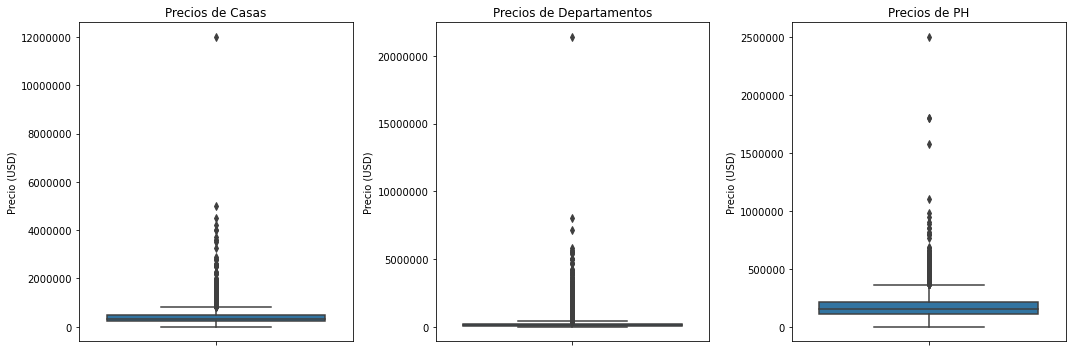

In [21]:
# Filtrar por tipo de propiedad: Casa, Departamento, PH
casas = train_df[train_df['type'] == 'Casa']
departamentos = train_df[train_df['type'] == 'Departamento']
ph = train_df[train_df['type'] == 'PH']

# Función para contar outliers usando el método IQR
def contar_outliers(df, columna):
    # Calcular cuartiles y rango intercuartílico
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites para identificar outliers
    rango_inferior = Q1 - 1.5 * IQR
    rango_superior = Q3 + 1.5 * IQR * 1.1

    # Contar outliers
    outliers = df[(df[columna] < rango_inferior) | (df[columna] > rango_superior)]
    return outliers.shape[0]

# Contar outliers en cada tipo de propiedad
cantidad_outliers_casas = contar_outliers(casas, 'price')
cantidad_outliers_departamentos = contar_outliers(departamentos, 'price')
cantidad_outliers_ph = contar_outliers(ph, 'price')

# Imprimir la cantidad de outliers para cada tipo de propiedad
print(f'Cantidad de outliers en Casas: {cantidad_outliers_casas}')
print(f'Cantidad de outliers en Departamentos: {cantidad_outliers_departamentos}')
print(f'Cantidad de outliers en PH: {cantidad_outliers_ph}')

# Crear una figura con 3 subgráficos (boxplots) para cada tipo de propiedad
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot para las Casas
sns.boxplot(data=casas, y='price', ax=axs[0])
axs[0].set_title('Precios de Casas')
axs[0].set_ylabel('Precio (USD)')
axs[0].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Boxplot para los Departamentos
sns.boxplot(data=departamentos, y='price', ax=axs[1])
axs[1].set_title('Precios de Departamentos')
axs[1].set_ylabel('Precio (USD)')
axs[1].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Boxplot para los PH
sns.boxplot(data=ph, y='price', ax=axs[2])
axs[2].set_title('Precios de PH')
axs[2].set_ylabel('Precio (USD)')
axs[2].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

En estos 3 boxplots vemos cómo encontramos valores extremos para casas y departamentos en mayor medida. Sin embargo, eliminaremos los outliers para contar con datos de mejor calidad

In [22]:
# Definir la función para eliminar outliers
def eliminar_outliers(df, columna):
    # Calcular cuartiles y rango intercuartílico
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Rango ajustado (ampliar el rango superior en un 10%)
    rango_inferior = Q1 - 1.5 * IQR
    rango_superior = Q3 + 1.5 * IQR * 1.1

    # Filtrar valores dentro del rango
    df_filtrado = df[(df[columna] >= rango_inferior) & (df[columna] <= rango_superior)]
    
    return df_filtrado

# Aplicar la función para eliminar outliers
casas_limpio = eliminar_outliers(casas, 'price')
departamentos_limpio = eliminar_outliers(departamentos, 'price')
ph_limpio = eliminar_outliers(ph, 'price')

# Unir todos los DataFrames limpios
clean_train_df = pd.concat([casas_limpio, departamentos_limpio, ph_limpio], ignore_index=True)

# Validar la eliminación de outliers
def validar_remocion_outliers(df_original, df_limpio, cantidad_outliers):
    # Calcular la diferencia en la cantidad de filas
    filas_originales = df_original.shape[0]
    filas_limpias = df_limpio.shape[0]
    filas_eliminadas = filas_originales - filas_limpias

    # Verificar si la cantidad de filas eliminadas coincide con los outliers identificados
    if filas_eliminadas == cantidad_outliers:
        print("Validación exitosa: Se eliminaron correctamente los", cantidad_outliers, "outliers.")
    else:
        print(f"Advertencia: La cantidad de outliers eliminados ({filas_eliminadas}) no coincide con la cantidad identificada ({cantidad_outliers}).")

# Validar para cada tipo de propiedad
validar_remocion_outliers(casas, casas_limpio, cantidad_outliers_casas)
validar_remocion_outliers(departamentos, departamentos_limpio, cantidad_outliers_departamentos)
validar_remocion_outliers(ph, ph_limpio, cantidad_outliers_ph)
train_df = clean_train_df

Validación exitosa: Se eliminaron correctamente los 187 outliers.
Validación exitosa: Se eliminaron correctamente los 5391 outliers.
Validación exitosa: Se eliminaron correctamente los 209 outliers.


A pesar de remover outliers, vemos que existen aún valores de propiedades menores que 10.000. A pesar de no ser identificados como outliers propiamente dichos, estos datos no tienen sentido desde un punto de vista real y práctico.

In [23]:
### REVISAR ESTO

In [24]:
# Contar la cantidad de propiedades con precios menores a 10000 USD
print(train_df[train_df['price'] < 10000].shape[0])

# Eliminar las propiedades con precios menores a 10000 USD
train_df = train_df[train_df['price'] >= 10000]

1261


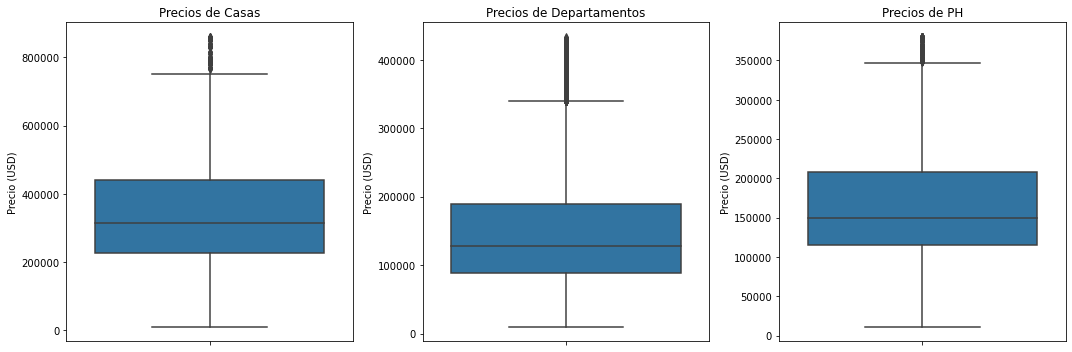

In [25]:
# Redefinir las variables para los boxplots sin outliers
casas = train_df[train_df['type'] == 'Casa']
departamentos = train_df[train_df['type'] == 'Departamento']
ph = train_df[train_df['type'] == 'PH']

# Graficar los boxplots sin outliers
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot para las Casas sin outliers
sns.boxplot(data=casas, y='price', ax=axs[0])
axs[0].set_title('Precios de Casas')
axs[0].set_ylabel('Precio (USD)')
axs[0].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Boxplot para los Departamentos sin outliers
sns.boxplot(data=departamentos, y='price', ax=axs[1])
axs[1].set_title('Precios de Departamentos')
axs[1].set_ylabel('Precio (USD)')
axs[1].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Boxplot para los PH sin outliers
sns.boxplot(data=ph, y='price', ax=axs[2])
axs[2].set_title('Precios de PH')
axs[2].set_ylabel('Precio (USD)')
axs[2].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

Vemos cómo los boxplots muestran una información más detallada y precisa. Los precios de las casas alcanzan un valor mucho más alto que las demás propiedades. Mientras que los departamentos y los PH cuentan con una distribución medianamente similar, pero que difiere en la cantidad de datos que salen del rango intercuartílico (los departamentos tienen muchos más)

#### 3.2 Estadística Descriptiva

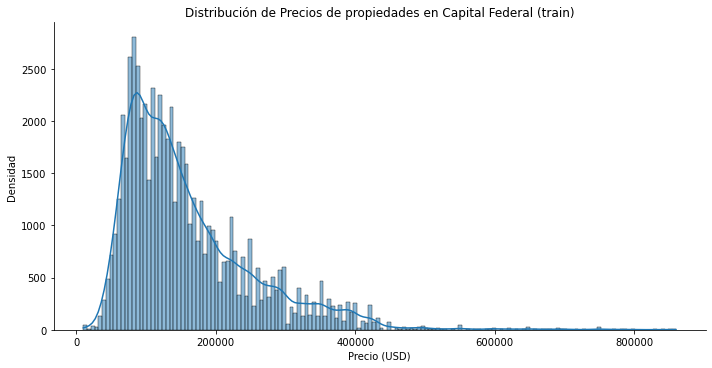

In [26]:
# Crear un gráfico de densidad para los precios de las casas.
sns.displot(train_df, x='price', kde=True, height=5, aspect=2)
plt.title('Distribución de Precios de propiedades en Capital Federal (train)')
plt.xlabel('Precio (USD)')
plt.ylabel('Densidad') 
plt.ticklabel_format(style='plain', axis='x')  
plt.show()

Vemos una distribución asimétrica positiva, lo cual tiene sentido para la variable que estamos estudiando. Vemos algunas propiedades cercanas al millón de dólares, las cuales, según los boxplots vistos anteriormente, son casas que tienen un valor elevado. 

In [27]:
# Evaluamos qué barrios tienen los precios más altos
barrios_precio_train = train_df.groupby('place_l3')['price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

# Redondear los precios a 2 decimales
barrios_precio_train['mean'] = barrios_precio_train['mean'].round(2)

# Mostrar los 10 barrios con los precios más altos
barrios_precio_train.head(10)

,mean,count
place_l3,,
Puerto Madero,290272.04,394
Las Cañitas,250000.00,5
Belgrano,196387.03,5193
Villa Devoto,193668.06,1362
Recoleta,193494.29,3587
Nuñez,181754.10,2438
Palermo,180483.55,8597
Villa Real,178769.79,96
Versalles,178692.31,220


comentar

#### 3.3 Análisis de correlación

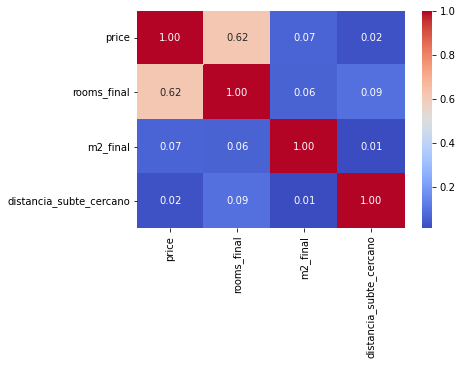

In [28]:
# Analizar la correlación entre las variables numéricas
correlacion = train_df[['price', 'rooms_final', 'm2_final', 'distancia_subte_cercano']].corr(method='pearson')
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")

Vemos que la cantidad de ambientes tiene una correlación bastante alta con el precio de la propiedad. Mientras que las demás variables del modelo parecen no tener una relación lineal. Exploremos con otro método para ver qué resultados obtenemos:

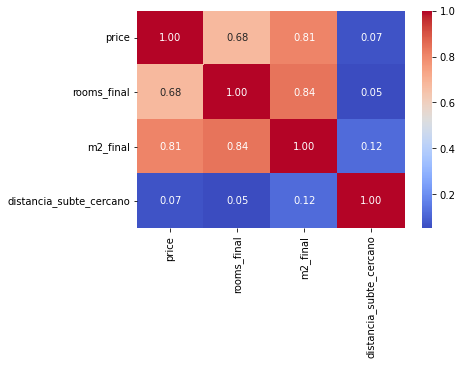

In [29]:
# Analizar la correlación entre las variables numéricas
correlacion = train_df[['price', 'rooms_final', 'm2_final', 'distancia_subte_cercano']].corr(method='spearman')
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")

Acá tenemos un hallazgo importante. Mientras que la cantidad de ambientes apenas mejoró con respecto a la correlación de Pearson, la cantidad de metros cuadrados contiene una relación no-lineal (curvilínea) con el precio de la propiedad. Mientras que la distancia al subte más cercano mejoró también su desempeño, pero de manera más leve.

Por lo tanto, se puede ir tanteando que la relación entre las features y el target es no-lineal.

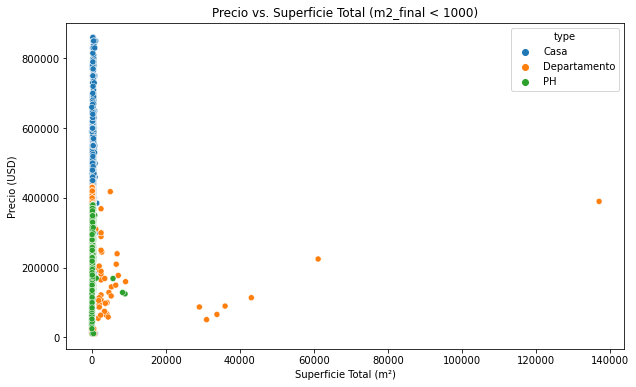

In [30]:
# Scatter plot de precio vs. superficie total para m2_final < 1000
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='m2_final', y='price', hue='type')
plt.title('Precio vs. Superficie Total (m2_final < 1000)')
plt.xlabel('Superficie Total (m²)')
plt.ylabel('Precio (USD)')
plt.show()

In [31]:
train_df[(train_df['m2_final'] > 700) & (train_df['type'] == 'Departamento')].shape[0]

52

En los casos donde la superficie total de los departamentos es más del doble que la superficie cubierta y la superficie total es mayor a 700 m², se reemplazará el valor de surface_total y m2_final con el valor de surface_covered. De lo contrario, los datos con superficie mayor a 700 m² tanto en superficie cubierta y superficie total serán descartados.

In [32]:
# Filtrar los registros que son de tipo "Departamento"
dept_mask_train = (train_df['type'] == 'Departamento')

# Reemplazar surface_total por surface_covered cuando surface_total es más del doble que surface_covered
train_df.loc[dept_mask_train & (train_df['surface_total'] > 2 * train_df['surface_covered']), 'surface_total'] = train_df['surface_covered']

# Reemplazar m2_final por surface_covered cuando m2_final es más del doble que surface_covered
train_df.loc[dept_mask_train & (train_df['m2_final'] > 2 * train_df['surface_covered']), 'm2_final'] = train_df['surface_covered']

train_df = train_df[~(dept_mask_train & (train_df['surface_total'] > 800))]

/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021_geopandas/lib/python3.7/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


Se chequean los departamentos y PHs con más de 15 habitaciones para detectar si existe alguna irregularidad o error.

In [33]:
filtered_df_train = train_df[(train_df['type'].isin(['Departamento', 'PH'])) & (train_df['bedrooms'] > 15)]
filtered_df_train

,id,start_date,end_date,created_on,latitud,longitud,place_l2,place_l3,operation,type,...,surface_total,surface_covered,price,title,rooms_total,rooms_final,m2_descripcion,m2_final,geometry,distancia_subte_cercano
10759,r3sXlEIiCgBG5TtUkN93mw==,2021-03-14,2021-06-05,2021-03-14,-34.608645,-58.485619,Capital Federal,Villa del Parque,Venta,Departamento,...,83.0,75.0,189000.0,Departamento 4 ambientes a estrenar en duplex ...,4.0,4.0,NaN,83.0,POINT (-58.48562 -34.60864),2.852656
27455,cMA0xBBQnANFa/wNTQtZcw==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Almagro,Venta,Departamento,...,111.0,76.0,270000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT (nan nan),NaN
30493,yzI9zylc11wllHX16av6jA==,2021-09-30,2021-11-02,2021-09-30,-34.632537,-58.360577,Capital Federal,Boca,Venta,Departamento,...,372.0,318.0,139000.0,DEPARTAMENTO PH 19 AMBIENTES AV ALMTE BROWN BOCA,19.0,19.0,NaN,372.0,POINT (-58.36058 -34.63254),1.988877
36677,f48xnLslZAFNd6aFyB7MZA==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Caballito,Venta,Departamento,...,111.0,76.0,245000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT (nan nan),NaN
40160,pVG9sES9De/1eQ+tB90NjQ==,2021-03-26,2021-06-05,2021-03-26,-34.591110,-58.400685,Capital Federal,Recoleta,Venta,Departamento,...,148.0,138.0,380000.0,Departamento. Recoleta. Balcón terraza. Silenc...,NaN,4.0,NaN,148.0,POINT (-58.40068 -34.59111),0.399894
43030,UVuiurLBb+DzTf73JSOI4g==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Almagro,Venta,Departamento,...,111.0,76.0,245000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT (nan nan),NaN
57877,uqM9/WXFJkEJnXEQefcpRQ==,2021-09-19,2021-09-19,2021-09-19,-34.611905,-58.382384,Capital Federal,Monserrat,Venta,PH,...,587.0,276.0,299900.0,PH DE16 HABITACIONES IDEAL PARA HOSTEL A RECI...,NaN,15.0,NaN,587.0,POINT (-58.38238 -34.61191),0.194591
58634,+SPkA/Y4DHEHf+HIppYFKg==,2021-03-31,2021-04-16,2021-03-31,-34.611905,-58.382384,Capital Federal,Monserrat,Venta,PH,...,587.0,276.0,349000.0,PH DE16 HABITACIONES IDEAL PARA HOSTEL A RECI...,NaN,15.0,NaN,587.0,POINT (-58.38238 -34.61191),0.194591
58791,TEs1aRnhJPwR0jRMq/Vzdg==,2021-08-03,9999-12-31,2021-08-03,-34.633236,-58.480313,Capital Federal,Floresta,Venta,PH,...,535.0,435.0,300000.0,"Hotel Familiar, 32 Habitaciones",33.0,32.0,NaN,535.0,POINT (-58.48031 -34.63324),1.018101
59073,CtbHDgBLf3+kTc20y2iVhw==,2021-11-29,2022-01-14,2021-11-29,-34.629796,-58.363928,Capital Federal,Boca,Venta,PH,...,386.0,323.0,145000.0,Hotel Comercial - Numerosos Ambientes! - Visit...,NaN,18.0,NaN,386.0,POINT (-58.36393 -34.62980),1.623333


Los inmuebles que tengan más de 15 habitaciones y estén clasificados como departamentos o PHs, pero cuya descripción contenga la palabra "hotel", serán eliminados. 

In [34]:
train_df = train_df[~((train_df['bedrooms'] > 15) & (train_df['title'].str.contains('hotel', case=False)))]
train_df[(train_df['type'].isin(['Departamento', 'PH'])) & (train_df['bedrooms'] > 15)]

,id,start_date,end_date,created_on,latitud,longitud,place_l2,place_l3,operation,type,...,surface_total,surface_covered,price,title,rooms_total,rooms_final,m2_descripcion,m2_final,geometry,distancia_subte_cercano
10759,r3sXlEIiCgBG5TtUkN93mw==,2021-03-14,2021-06-05,2021-03-14,-34.608645,-58.485619,Capital Federal,Villa del Parque,Venta,Departamento,...,83.0,75.0,189000.0,Departamento 4 ambientes a estrenar en duplex ...,4.0,4.0,NaN,83.0,POINT (-58.48562 -34.60864),2.852656
27455,cMA0xBBQnANFa/wNTQtZcw==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Almagro,Venta,Departamento,...,111.0,76.0,270000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT (nan nan),NaN
30493,yzI9zylc11wllHX16av6jA==,2021-09-30,2021-11-02,2021-09-30,-34.632537,-58.360577,Capital Federal,Boca,Venta,Departamento,...,372.0,318.0,139000.0,DEPARTAMENTO PH 19 AMBIENTES AV ALMTE BROWN BOCA,19.0,19.0,NaN,372.0,POINT (-58.36058 -34.63254),1.988877
36677,f48xnLslZAFNd6aFyB7MZA==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Caballito,Venta,Departamento,...,111.0,76.0,245000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT (nan nan),NaN
40160,pVG9sES9De/1eQ+tB90NjQ==,2021-03-26,2021-06-05,2021-03-26,-34.591110,-58.400685,Capital Federal,Recoleta,Venta,Departamento,...,148.0,138.0,380000.0,Departamento. Recoleta. Balcón terraza. Silenc...,NaN,4.0,NaN,148.0,POINT (-58.40068 -34.59111),0.399894
43030,UVuiurLBb+DzTf73JSOI4g==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Almagro,Venta,Departamento,...,111.0,76.0,245000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT (nan nan),NaN
57877,uqM9/WXFJkEJnXEQefcpRQ==,2021-09-19,2021-09-19,2021-09-19,-34.611905,-58.382384,Capital Federal,Monserrat,Venta,PH,...,587.0,276.0,299900.0,PH DE16 HABITACIONES IDEAL PARA HOSTEL A RECI...,NaN,15.0,NaN,587.0,POINT (-58.38238 -34.61191),0.194591
58634,+SPkA/Y4DHEHf+HIppYFKg==,2021-03-31,2021-04-16,2021-03-31,-34.611905,-58.382384,Capital Federal,Monserrat,Venta,PH,...,587.0,276.0,349000.0,PH DE16 HABITACIONES IDEAL PARA HOSTEL A RECI...,NaN,15.0,NaN,587.0,POINT (-58.38238 -34.61191),0.194591
59273,KA441xdi8PtuWBvjcAbGOQ==,2021-02-08,2021-03-01,2021-02-08,-34.632698,-58.360514,Capital Federal,Boca,Venta,PH,...,372.0,318.0,159000.0,PH 18 HABITACIONES AV ALMTE BROWN LA BOCA,19.0,19.0,NaN,372.0,POINT (-58.36051 -34.63270),1.999377


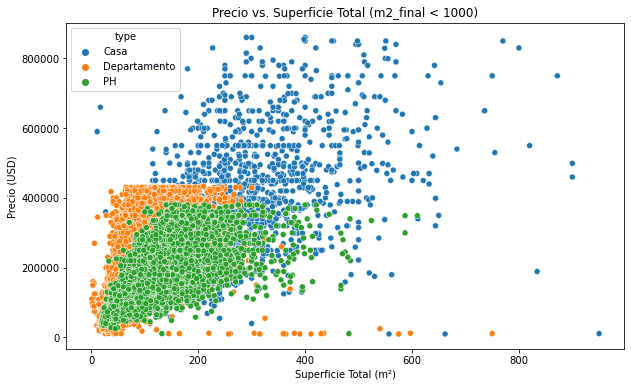

In [35]:
# Scatter plot de precio vs. superficie total para m2_final < 1000
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df[train_df['m2_final'] < 1000], x='m2_final', y='price', hue='type')
plt.title('Precio vs. Superficie Total (m2_final < 1000)')
plt.xlabel('Superficie Total (m²)')
plt.ylabel('Precio (USD)')
plt.show()

Por temas de escala, recortamos los datos para visualizarlos. Este gráfico se condice con lo planteado en el análisis de la correlación: la cantidad de metros cuadrados si es importante para el modelo.

Sin embargo, vemos que hay casas con más de 600 metros cuadrados que tienen precios bastante bajos. Exploraremos qué sucede si hacemos el gráfico de manera aislada para cada tipo de propiedad

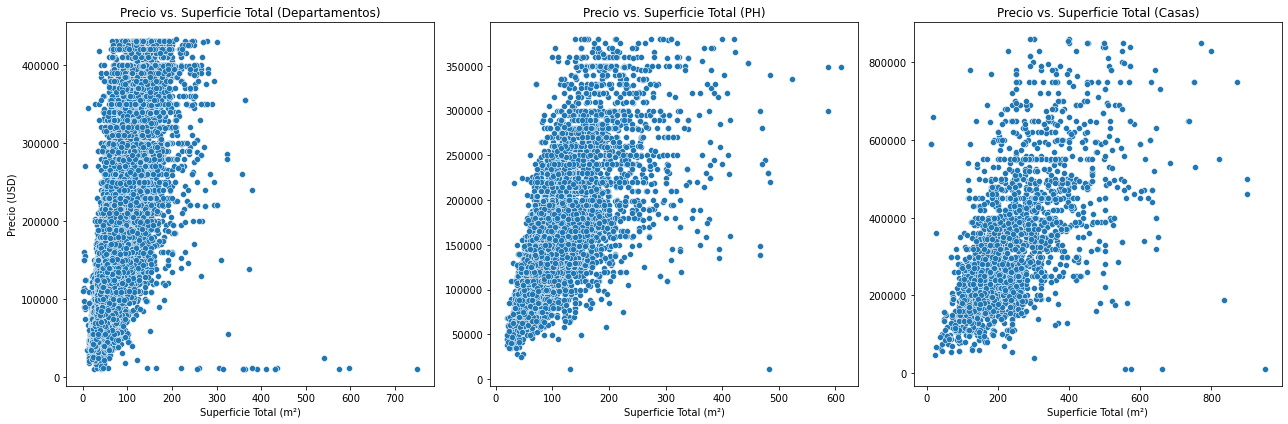

In [36]:
# Crearemos el gráfico solicitado sin crear nuevas variables

# Creamos una figura con un grid de 3 gráficos (1 fila y 3 columnas)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Scatter plot para Departamentos
sns.scatterplot(data=train_df[(train_df['m2_final'] < 1000) & (train_df['type'] == 'Departamento')], x='m2_final', y='price', ax=axs[0])
axs[0].set_title('Precio vs. Superficie Total (Departamentos)')
axs[0].set_xlabel('Superficie Total (m²)')
axs[0].set_ylabel('Precio (USD)')

# Scatter plot para PH
sns.scatterplot(data=train_df[(train_df['m2_final'] < 1000) & (train_df['type'] == 'PH')], x='m2_final', y='price', ax=axs[1])
axs[1].set_title('Precio vs. Superficie Total (PH)')
axs[1].set_xlabel('Superficie Total (m²)')
axs[1].set_ylabel('')

# Scatter plot para Casas
sns.scatterplot(data=train_df[(train_df['m2_final'] < 1000) & (train_df['type'] == 'Casa')], x='m2_final', y='price', ax=axs[2])
axs[2].set_title('Precio vs. Superficie Total (Casas)')
axs[2].set_xlabel('Superficie Total (m²)')
axs[2].set_ylabel('')

# Ajustamos el espacio entre gráficos
plt.tight_layout()
plt.show()

In [37]:
# COMENTARLO

### 4. Comparación de datasets de train y test

In [38]:
# Filtrar por tipo de propiedad: Casa, Departamento, PH
casas = test_df[test_df['type'] == 'Casa']
departamentos = test_df[test_df['type'] == 'Departamento']
ph = test_df[test_df['type'] == 'PH']

# Contar outliers en cada tipo de propiedad
cantidad_outliers_casas = contar_outliers(casas, 'price')
cantidad_outliers_departamentos = contar_outliers(departamentos, 'price')
cantidad_outliers_ph = contar_outliers(ph, 'price')

# Imprimir la cantidad de outliers para cada tipo de propiedad
print(f'Cantidad de outliers en Casas: {cantidad_outliers_casas}')
print(f'Cantidad de outliers en Departamentos: {cantidad_outliers_departamentos}')
print(f'Cantidad de outliers en PH: {cantidad_outliers_ph}')

Cantidad de outliers en Casas: 33
Cantidad de outliers en Departamentos: 1299
Cantidad de outliers en PH: 64


In [39]:
# Aplicar la función para eliminar outliers
casas_limpio = eliminar_outliers(casas, 'price')
departamentos_limpio = eliminar_outliers(departamentos, 'price')
ph_limpio = eliminar_outliers(ph, 'price')

# Unir todos los DataFrames limpios
clean_test_df = pd.concat([casas_limpio, departamentos_limpio, ph_limpio], ignore_index=True)

# Validar para cada tipo de propiedad
validar_remocion_outliers(casas, casas_limpio, cantidad_outliers_casas)
validar_remocion_outliers(departamentos, departamentos_limpio, cantidad_outliers_departamentos)
validar_remocion_outliers(ph, ph_limpio, cantidad_outliers_ph)
test_df = clean_test_df

Validación exitosa: Se eliminaron correctamente los 33 outliers.
Validación exitosa: Se eliminaron correctamente los 1299 outliers.
Validación exitosa: Se eliminaron correctamente los 64 outliers.


In [40]:
# Contar la cantidad de propiedades con precios menores a 10000 USD
print(test_df[test_df['price'] < 10000].shape[0])

# Eliminar las propiedades con precios menores a 10000 USD
test_df = test_df[test_df['price'] >= 10000]

342


Se chequea si hay propiedades con más de 700 m2 en el conjunto de prueba, de igual forma que en el conjunto de entrenamiento

In [41]:
test_df[(test_df['m2_final'] > 700) & (test_df['type'] == 'Departamento')].shape[0]

19

In [42]:
test_df[(test_df['m2_final'] > 700) & (test_df['type'] == 'Departamento')]

,id,start_date,end_date,created_on,latitud,longitud,place_l2,place_l3,operation,type,...,surface_total,surface_covered,price,title,rooms_total,rooms_final,m2_descripcion,m2_final,geometry,distancia_subte_cercano
1929,8b+CSpRNOTjFl1WESiegUg==,2021-08-21,2021-08-27,2021-08-21,-34.554356,-58.458076,Capital Federal,Belgrano,Venta,Departamento,...,2500.0,51.0,164900.0,VENTA DEPARTAMENTO 2 AMBIENTES PISO ALTO BELGRANO,2.0,2.0,NaN,2500.0,POINT (-58.45808 -34.55436),0.419844
2602,MYZD6oNPlLhMzVLoEbL9jw==,2021-10-05,2021-11-04,2021-10-05,-34.579163,-58.455725,Capital Federal,Colegiales,Venta,Departamento,...,31000.0,26.0,51100.0,Av. Alvarez Thomas 970 - Colegiales - Capital ...,NaN,1.0,NaN,31000.0,POINT (-58.45572 -34.57916),0.893588
2707,zMligt7YdiayCjrfqlmbfg==,2021-01-05,2021-01-09,2021-01-05,-34.628247,-58.437696,Capital Federal,Caballito,Venta,Departamento,...,18096.0,8568.0,324558.0,4 Ambientes Venta de Pozo Caballito Full Ameni...,4.0,4.0,NaN,18096.0,POINT (-58.43770 -34.62825),0.356679
3109,adGY6/gjcj/MfuSQmZg7jw==,2021-09-03,2021-09-03,2021-09-03,-34.554356,-58.458076,Capital Federal,Belgrano,Venta,Departamento,...,2500.0,51.0,159000.0,VENTA DEPARTAMENTO 2 AMBIENTES BELGRANO CON BA...,2.0,2.0,NaN,2500.0,POINT (-58.45808 -34.55436),0.419844
3197,WQU6YIN+y4z30xaPRG4LHQ==,2021-03-07,2022-02-09,2021-03-07,-34.636532,-58.376406,Capital Federal,Barracas,Venta,Departamento,...,72060.0,90.0,210000.0,"VENTA SEMIPISO 4 AMBIENTES, EXCELENTE OPORTUIDAD",4.0,4.0,NaN,72060.0,POINT (-58.37641 -34.63653),1.090971
4306,OX8EKol2msy5QGViKBzvqw==,2021-02-13,2021-03-01,2021-02-13,-34.624845,-58.431635,Capital Federal,Caballito,Venta,Departamento,...,1870.0,45.0,93900.0,Emprendimiento - Venta 2 amb - CABALLITO SUR,NaN,2.0,NaN,1870.0,POINT (-58.43163 -34.62485),0.404812
4308,XzTb7kTEpmAKiyhEGSWz4A==,2021-08-24,2021-09-03,2021-08-24,-34.555278,-58.459786,Capital Federal,Belgrano,Venta,Departamento,...,100068.0,100051.0,420000.0,VENTA PISO 4 AMBIENTES BELGRANO COCHERA BALCON,4.0,4.0,NaN,100068.0,POINT (-58.45979 -34.55528),0.241312
4732,G7sKDYpvhrBrps0xzAQrmQ==,2021-01-16,2021-04-14,2021-01-16,-34.579163,-58.455725,Capital Federal,Colegiales,Venta,Departamento,...,31000.0,26.0,51100.0,Av. Alvarez Thomas 970 - Colegiales - Capital ...,NaN,1.0,NaN,31000.0,POINT (-58.45572 -34.57916),0.893588
5604,rGOjA8tJXYsGapcTNwIKQA==,2021-05-28,2021-06-13,2021-05-28,-34.603992,-58.500042,Capital Federal,Villa del Parque,Venta,Departamento,...,3623.0,3615.0,110000.0,VENTA MONOAMB VILLA DEL PARQUE CON COCHERA,NaN,1.0,NaN,3623.0,POINT (-58.50004 -34.60399),3.389881
6897,McdySYNyXo2s4UZ2wypUig==,2021-03-20,2022-03-25,2021-03-20,-34.606260,-58.452737,Capital Federal,Villa Crespo,Venta,Departamento,...,4224.0,4224.0,100000.0,VENTA DEPARTAMENTO 2 AMBIENTES VILLA CRESPO,2.0,2.0,NaN,4224.0,POINT (-58.45274 -34.60626),1.438363


In [43]:
# Filtrar los registros que son de tipo "Departamento"
dept_mask_test = (test_df['type'] == 'Departamento')

# Reemplazar surface_total por surface_covered cuando surface_total es más del doble que surface_covered
test_df.loc[dept_mask_test & (test_df['surface_total'] > 2 * test_df['surface_covered']), 'surface_total'] = test_df['surface_covered']

# Reemplazar m2_final por surface_covered cuando m2_final es más del doble que surface_covered
test_df.loc[dept_mask_test & (test_df['m2_final'] > 2 * test_df['surface_covered']), 'm2_final'] = test_df['surface_covered']

test_df = test_df[~(dept_mask_test & (test_df['surface_total'] > 700))]

/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021_geopandas/lib/python3.7/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


Lo mismo se hace con la cantidad de habitaciones, si existen datos que tengan más habitaciones que ambientes

In [44]:
#inmuebles que tengan más habitaciones que ambientes
test_df[test_df['bedrooms'] > test_df['rooms_final']]

,id,start_date,end_date,created_on,latitud,longitud,place_l2,place_l3,operation,type,...,surface_total,surface_covered,price,title,rooms_total,rooms_final,m2_descripcion,m2_final,geometry,distancia_subte_cercano
94,U+eSSM88Ljzr3NMDIv1Pfg==,2021-04-13,2021-08-26,2021-04-13,-34.608162,-58.453786,Capital Federal,Caballito,Venta,Casa,...,366.0,140.0,320000.0,Casa de 7 ambientes en Venta en Caballito,7.0,5.0,NaN,366.0,POINT (-58.45379 -34.60816),1.640996
445,OOz88YCCX3+F85n3z/yoiQ==,2021-10-15,2022-03-25,2021-10-15,-34.573955,-58.469930,Capital Federal,Belgrano,Venta,Casa,...,409.0,250.0,790000.0,EXCELENTE CASA DE 3 PLANTAS EN BELGRANO R,NaN,4.0,NaN,409.0,POINT (-58.46993 -34.57396),0.900586
634,gg6+Wj9KRWOi92ri7KuuXw==,2021-02-13,2021-03-20,2021-02-13,-34.637611,-58.402928,Capital Federal,Parque Patricios,Venta,Departamento,...,66.0,50.0,105000.0,3 Amb c/TERRAZA PROPIA DE 16 M2,NaN,1.0,16.0,66.0,POINT (-58.40293 -34.63761),0.277255
2976,mAzAqXdmAZYrERB6k3F51w==,2021-01-22,2021-08-31,2021-01-22,-34.585134,-58.394394,Capital Federal,Recoleta,Venta,Departamento,...,79.0,69.0,300000.0,"BOMBONCITO!, semipiso alegre con vista a los j...",NaN,3.0,NaN,79.0,POINT (-58.39439 -34.58513),0.365624
3893,O/JMW/VVo7OmWF7SkXtBuA==,2021-10-16,2021-12-24,2021-10-16,-34.630186,-58.389156,Capital Federal,Parque Patricios,Venta,Departamento,...,32.0,32.0,52000.0,Depto 1 ambiente amplio apto profesional,NaN,1.0,NaN,32.0,POINT (-58.38916 -34.63019),0.763138
4901,DS1iUNdl57jXeTtnrfNcow==,2021-02-13,2021-03-01,2021-02-13,-34.626357,-58.509107,Capital Federal,Versalles,Venta,Departamento,...,38.0,38.0,80700.0,TORRE VERSALLES - DEPARTAMENTO - 1 AMB - VERSA...,NaN,1.0,NaN,38.0,POINT (-58.50911 -34.62636),3.651142
7071,q5mE4qv6OxYNWlMis+Mwig==,2021-02-06,2021-07-20,2021-02-06,-34.650211,-58.503437,Capital Federal,Mataderos,Venta,Departamento,...,120.0,112.0,155000.0,Espectacular Departamento Piso Unico!,NaN,1.0,NaN,120.0,POINT (-58.50344 -34.65021),3.779354
8326,azlGDc44w5UKu1Ft0aWdLA==,2021-03-08,2021-06-05,2021-03-08,-34.623053,-58.447006,Capital Federal,Caballito,Venta,Departamento,...,145.0,135.0,299000.0,Departamento - Caballito,NaN,4.0,NaN,145.0,POINT (-58.44701 -34.62305),0.159518
10116,fMWvtL8AM9C46nTizyJ0SQ==,2021-02-05,2021-03-25,2021-02-05,-34.614128,-58.437675,Capital Federal,Caballito,Venta,Departamento,...,82.0,75.0,179000.0,Departamento - Caballito,NaN,4.0,NaN,82.0,POINT (-58.43767 -34.61413),0.474578
11307,PfSrBA7qDBzgseJ4JyQF/w==,2021-04-28,2021-08-31,2021-04-28,-34.637611,-58.402928,Capital Federal,Parque Patricios,Venta,Departamento,...,32.0,28.0,64000.0,Monoambiente c/balcon. Parque Patricios,1.0,1.0,NaN,32.0,POINT (-58.40293 -34.63761),0.277255


In [45]:
test_df = test_df[~(test_df['bedrooms'] > test_df['rooms_final'])]

Al igual que con los datos de prueba, se chequean los departamentos y PHs con más de 15 habitaciones para detectar si existe alguna irregularidad o error.

In [46]:
filtered_df_test = test_df[(test_df['type'].isin(['Departamento', 'PH'])) & (test_df['bedrooms'] > 15)]
filtered_df_test

,id,start_date,end_date,created_on,latitud,longitud,place_l2,place_l3,operation,type,...,surface_total,surface_covered,price,title,rooms_total,rooms_final,m2_descripcion,m2_final,geometry,distancia_subte_cercano
8244,760pAR/aW7whZAZRLML/ZA==,2021-09-17,2022-02-25,2021-09-17,-34.611905,-58.382384,Capital Federal,Monserrat,Venta,Departamento,...,554.0,334.0,240000.0,Hotel en Venta - 17 habitaciones - Terraza Pro...,18.0,18.0,NaN,554.0,POINT (-58.38238 -34.61191),0.194591


En este caso no se elimina ningún dato, ya que la descripción cumple con la clasificación en la columna type.

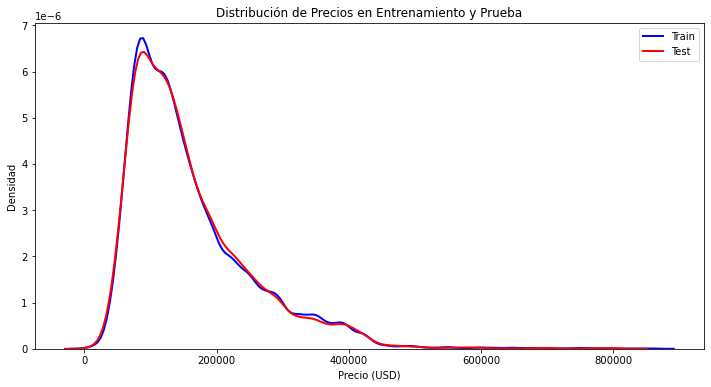

In [47]:
# Analisis de distribucion de precios en el conjunto de entrenamiento y prueba
plt.figure(figsize=(12, 6))
sns.kdeplot(data=train_df['price'], label='Train', color='blue', linewidth=2)
sns.kdeplot(data=test_df['price'], label='Test', color='red', linewidth=2)
plt.title('Distribución de Precios en Entrenamiento y Prueba')
plt.xlabel('Precio (USD)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

In [48]:
# Aplicar el test de Kolmogorov-Smirnov a la variable 'price'
ks_statistic, p_value = stats.ks_2samp(train_df['price'], test_df['price'])

# Imprimir los resultados
print(f'Estadístico K-S: {ks_statistic}')
print(f'Valor p: {p_value}')
if p_value < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.')

Estadístico K-S: 0.006687209367731706
Valor p: 0.6268112821347384
No se rechaza la hipótesis nula: Las distribuciones son iguales.


Sabemos que el barrio es determinante para predecir el precio de la propiedad. Por lo tanto, debemos asegurarnos de que al dividir el dataset en train y test contemos con una proporción similar. Por lo tanto, vamos a aplicar un test de Chi cuadrado a ver si las proporciones entre ambos datasets son similares

In [49]:
# import chi2_contingency
from scipy.stats import chi2_contingency

# Contamos las ocurrencias de cada barrio en los datasets de train y test
train_counts = train_df['place_l3'].value_counts(normalize=True)  # Normalizamos el conteo (proporciones)
test_counts = test_df['place_l3'].value_counts(normalize=True)    # Normalizamos el conteo (proporciones)

# Unimos ambos conteos en un dataframe
counts_df = pd.DataFrame({'train': train_counts, 'test': test_counts}).fillna(0)

# Aplicamos la prueba de Chi cuadrado
chi2_stat, p_val, dof, expected = chi2_contingency(counts_df)

# Mostramos los resultados
print(f"Estadístico Chi2: {chi2_stat}")
print(f"P-valor: {p_val}")
if p_value < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.')

Estadístico Chi2: 0.002027440625048931
P-valor: 1.0
No se rechaza la hipótesis nula: Las distribuciones son iguales.


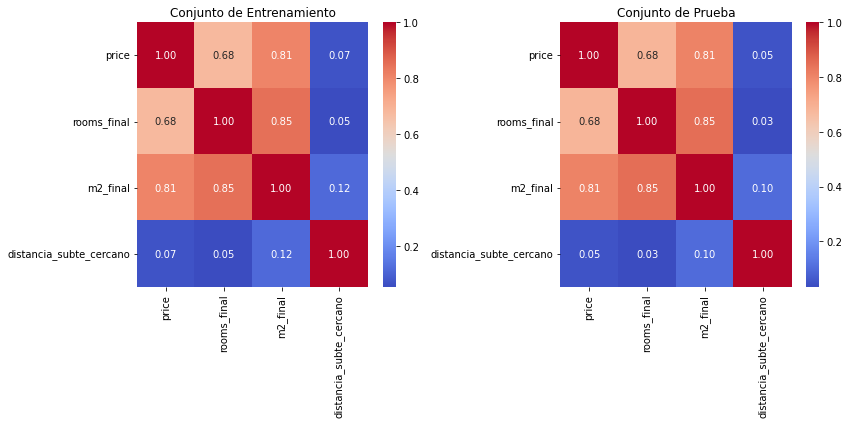

In [50]:
# Comparación de matrices de correlación
correlacion_train = train_df[['price', 'rooms_final', 'm2_final', 'distancia_subte_cercano']].corr(method='spearman')
correlacion_test = test_df[['price', 'rooms_final', 'm2_final', 'distancia_subte_cercano']].corr(method='spearman')

# Crear una figura con 2 subgráficos (heatmap) para comparar las correlaciones
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Heatmap para el conjunto de entrenamiento
sns.heatmap(correlacion_train, annot=True, cmap='coolwarm', fmt=".2f", ax=axs[0])
axs[0].set_title('Conjunto de Entrenamiento')

# Heatmap para el conjunto de prueba
sns.heatmap(correlacion_test, annot=True, cmap='coolwarm', fmt=".2f", ax=axs[1])
axs[1].set_title('Conjunto de Prueba')

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

No hay diferencias signiticativas entre las correlaciones entre ambos datasets. La distancia al subte más cercano está levemente menos correlacionada en el test, pero no es una diferencia demasiado grande.

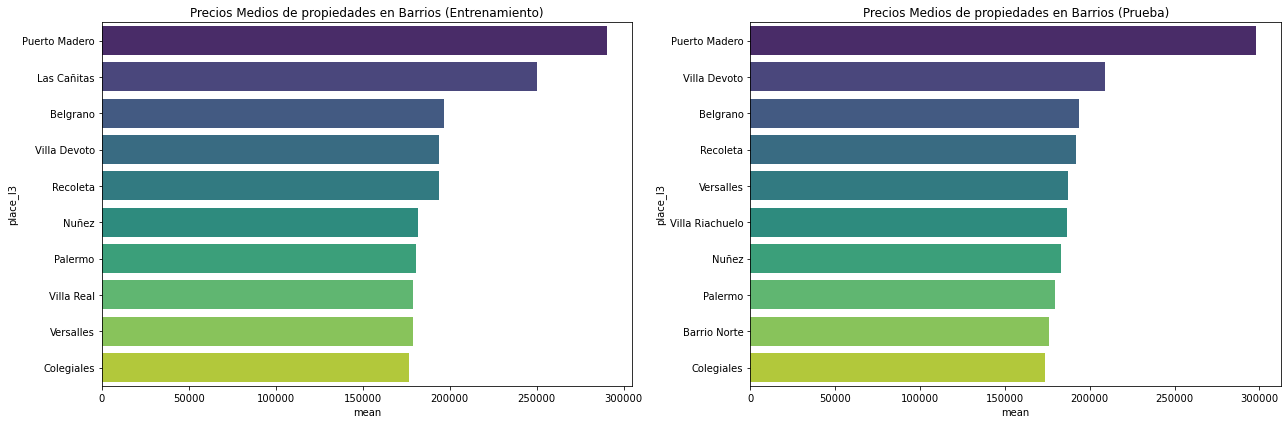

In [51]:
# Comparamos los barrios con más precios altos en el conjunto de entrenamiento y prueba
barrios_precio_test = test_df.groupby('place_l3')['price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

# Redondear los precios a 2 decimales
barrios_precio_test['mean'] = barrios_precio_test['mean'].round(2)

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico de barras para el conjunto de entrenamiento
sns.barplot(data=barrios_precio_train.head(10), x='mean', y=barrios_precio_train.head(10).index, ax=axs[0], palette='viridis')
axs[0].set_title('Precios Medios de propiedades en Barrios (Entrenamiento)')

# Gráfico de barras para el conjunto de prueba
sns.barplot(data=barrios_precio_test.head(10), x='mean', y=barrios_precio_test.head(10).index, ax=axs[1], palette='viridis')
axs[1].set_title('Precios Medios de propiedades en Barrios (Prueba)')
plt.tight_layout()
plt.show()

Comentarios sobre comparación de esto

### 4. Procesamiento para aplicar regresión lineal

#### 4.1 Imputación de valores nulos

In [52]:
print('Porcentaje de nulos en cada columna:')
print('rooms_final:', (train_df.rooms_final.isnull().sum()/train_df.shape[0])*100)
print('m2_final:', (train_df.m2_final.isnull().sum()/train_df.shape[0])*100)
print('distancia_subte_cercano:', (train_df.distancia_subte_cercano.isnull().sum()/train_df.shape[0])*100)

Porcentaje de nulos en cada columna:
rooms_final: 0.0
m2_final: 0.0
distancia_subte_cercano: 3.524587548265629


In [53]:
import pandas as pd
from scipy import stats

# Hacer una copia de los dataframes originales
train_df_copy = train_df.copy()
test_df_copy = test_df.copy()

# 1. Comparar 'train_df' antes y después de la imputación
# Test de Kolmogorov-Smirnov en los datos originales de train (antes de la imputación)
ks_stat_train_before, p_value_train_before = stats.ks_2samp(train_df['distancia_subte_cercano'].dropna(), train_df_copy['distancia_subte_cercano'].dropna())
print(f"Train - Antes de la imputación:")
print(f'Estadístico K-S: {ks_stat_train_before}')
print(f'Valor p: {p_value_train_before}')
if p_value_train_before < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.\n')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.\n')

# Imputar los valores nulos en el DataFrame 'train_df' con la media por 'place_l3'
train_df_copy['distancia_subte_cercano'] = train_df_copy.groupby('place_l3')['distancia_subte_cercano'].transform(lambda x: x.fillna(x.mean()))

# Test de Kolmogorov-Smirnov en los datos de train (después de la imputación)
ks_stat_train_after, p_value_train_after = stats.ks_2samp(train_df['distancia_subte_cercano'].dropna(), train_df_copy['distancia_subte_cercano'].dropna())
print(f"Train - Después de la imputación:")
print(f'Estadístico K-S: {ks_stat_train_after}')
print(f'Valor p: {p_value_train_after}')
if p_value_train_after < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.\n')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.\n')


# 2. Comparar 'test_df' antes y después de la imputación
# Test de Kolmogorov-Smirnov en los datos originales de test (antes de la imputación)
ks_stat_test_before, p_value_test_before = stats.ks_2samp(test_df['distancia_subte_cercano'].dropna(), test_df_copy['distancia_subte_cercano'].dropna())
print(f"Test - Antes de la imputación:")
print(f'Estadístico K-S: {ks_stat_test_before}')
print(f'Valor p: {p_value_test_before}')
if p_value_test_before < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.\n')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.\n')

# Imputar los valores nulos en el DataFrame 'test_df' con la media por 'place_l3'
test_df_copy['distancia_subte_cercano'] = test_df_copy.groupby('place_l3')['distancia_subte_cercano'].transform(lambda x: x.fillna(x.mean()))

# Test de Kolmogorov-Smirnov en los datos de test (después de la imputación)
ks_stat_test_after, p_value_test_after = stats.ks_2samp(test_df['distancia_subte_cercano'].dropna(), test_df_copy['distancia_subte_cercano'].dropna())
print(f"Test - Después de la imputación:")
print(f'Estadístico K-S: {ks_stat_test_after}')
print(f'Valor p: {p_value_test_after}')
if p_value_test_after < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.\n')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.\n')

Train - Antes de la imputación:
Estadístico K-S: 0.0
Valor p: 1.0
No se rechaza la hipótesis nula: Las distribuciones son iguales.

Train - Después de la imputación:
Estadístico K-S: 0.010205463834251582
Valor p: 0.0032847968598556606
Se rechaza la hipótesis nula: Las distribuciones son diferentes.

Test - Antes de la imputación:
Estadístico K-S: 0.0
Valor p: 1.0
No se rechaza la hipótesis nula: Las distribuciones son iguales.

Test - Después de la imputación:
Estadístico K-S: 0.010500262241990521
Valor p: 0.36201485508390396
No se rechaza la hipótesis nula: Las distribuciones son iguales.



Vemos que las distribuciones son iguales. Por lo que tomamos como válida la imputación y reemplazamos el dataset creado por el 

In [54]:
# Reemplazar los datasets originales con los datasets imputados
train_df = train_df_copy
test_df = test_df_copy

In [55]:
print(f"Valores nulos en 'place_l3': {train_df_copy['place_l3'].isnull().sum()/train_df_copy.shape[0]*100:.2f}%")
print(f"Valores nulos en 'place_l3': {test_df_copy['place_l3'].isnull().sum()/test_df_copy.shape[0]*100:.2f}%")

Valores nulos en 'place_l3': 0.18%
Valores nulos en 'place_l3': 0.17%


Tenemos muy pocos datos con place_l3 con nulos. Estos datos complican la imputación de valores, y serán problemáticos más adelante.

In [56]:
# Remover las filas con valores nulos en 'place_l3'
train_df = train_df.dropna(subset=['place_l3'])

test_df = test_df.dropna(subset=['place_l3'])

#### 4.2 Tratamiento de variables categóricas

In [57]:
# Generar variables dummies para las columnas 'type' y 'place_l3'
train_df = pd.get_dummies(train_df, columns=['place_l3', 'type'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['place_l3', 'type'], drop_first=True)

In [58]:
# Eliminar id, start_date, end_date, created_on, latitud, longitud, place_l2, operation, type, rooms, bedrooms, surface_total, surface_covered, title, geometry, m2_descripcion]
train_df = train_df.drop(['id', 'start_date', 'end_date', 'created_on', 'latitud', 'longitud', 'place_l2', 'operation',  'rooms', 'bedrooms', 'surface_total', 'surface_covered', 'title', 'geometry', 'm2_descripcion'], axis=1)

In [59]:
# Eliminar id, start_date, end_date, created_on, latitud, longitud, place_l2, operation, type, rooms, bedrooms, surface_total, surface_covered, title, geometry, m2_descripcion]
test_df = test_df.drop(['id', 'start_date', 'end_date', 'created_on', 'latitud', 'longitud', 'place_l2', 'operation', 'rooms', 'bedrooms', 'surface_total', 'surface_covered', 'title', 'geometry', 'm2_descripcion'], axis=1)

In [60]:
# Eliminar rooms_total
train_df = train_df.drop(['rooms_total'], axis=1)
test_df = test_df.drop(['rooms_total'], axis=1)

# 

#### 4.3 Normalización de variables

In [61]:
# Normalizar las variables numéricas

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar el escalador con el conjunto de entrenamiento
scaler.fit(train_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']])

StandardScaler()

### 5. Regresión Lineal

In [62]:
# Escalar las variables numéricas
train_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']] = scaler.transform(train_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']])

# Ajustar el escalador con el conjunto de prueba
scaler.fit(test_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']])

# Escalar las variables numéricas
test_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']] = scaler.transform(test_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']])

# Separar las variables independientes y la variable objetivo
X_train = train_df.drop('price', axis=1)
y_train = train_df['price']

# Separar las variables independientes y la variable objetivo
X_test = test_df.drop('price', axis=1)
y_test = test_df['price']

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.890
Model:                            OLS   Adj. R-squared (uncentered):              0.890
Method:                 Least Squares   F-statistic:                              8296.
Date:                Thu, 07 Nov 2024   Prob (F-statistic):                        0.00
Time:                        00:09:40   Log-Likelihood:                     -7.7874e+05
No. Observations:               62559   AIC:                                  1.558e+06
Df Residuals:                   62498   BIC:                                  1.558e+06
Df Model:                          61                                                  
Covariance Type:            nonrobust                                                  
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------

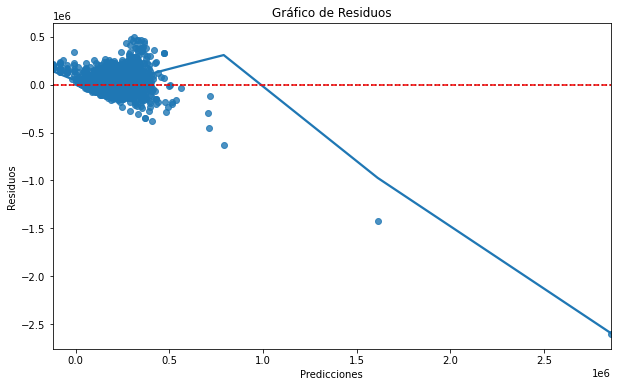

In [63]:
model = sm.OLS(y_train, X_train).fit()

print(model.summary())
#Se realizan predicciones y RMSE
predictions = model.predict(X_test)
rmse = np.sqrt(np.mean((predictions - y_test) ** 2))
print(f'RMSE: {rmse}')
#Visualizamos errores residuales
plt.figure(figsize=(10, 6))
sns.residplot(x=predictions, y=y_test - predictions, lowess=True)
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [64]:
#Evaluar el modelo en el conjunto de prueba
r2 = r2_score(y_test, predictions)
print(f'R2 Score: {r2}')

R2 Score: 0.4660556127264217


### Implementación de XGBoost (Modelo más avanzado)

In [66]:
# Definimos el modelo XGBoost para regresión
model_xg = XGBRegressor(n_jobs=-1, random_state=5)

# Creamos la grilla de hiperparámetros
params_xgb = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 3]
}

# Instanciamos el KFold
cv = KFold(n_splits=5, random_state=41, shuffle=True)

# Definimos el GridSearchCV
grid_search = GridSearchCV(model_xg, param_grid=params_xgb, cv=cv, verbose=1, n_jobs=2)

# Definimos el RandomizedSearchCV
random_search = RandomizedSearchCV(model_xg, param_distributions=params_xgb, cv=cv, 
                                   verbose=1, n_jobs=2, n_iter=10, random_state=42)

# Ajustamos el modelo con GridSearchCV
grid_search.fit(X_train, y_train)
print("Mejor estimador encontrado por GridSearchCV:")
print(grid_search.best_estimator_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor estimador encontrado por GridSearchCV:
XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=1000,
             n_jobs=-1, num_parallel_tree=1, predictor='auto', random_state=5,
             reg_alpha=0, reg_lambda=1, ...)


### Almacenar el modelo para después ser implementado en la pipeline

In [67]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

# Definimos el modelo XGBoost para regresión con hiperparámetros específicos
model_xg = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=5, n_jobs=-1, random_state=5)

# Definimos el KFold para la validación cruzada
cv = KFold(n_splits=5, random_state=41, shuffle=True)

# Definimos los 'scorers' para RMSE y R²
rmse_scorer = make_scorer(mean_squared_error, squared=False)  # RMSE
r2_scorer = make_scorer(r2_score)  # R²

# Calculamos el puntaje de validación cruzada para RMSE
rmse_scores = cross_val_score(model_xg, X_train, y_train, cv=cv, scoring=rmse_scorer)

# Calculamos el puntaje de validación cruzada para R²
r2_scores = cross_val_score(model_xg, X_train, y_train, cv=cv, scoring=r2_scorer)

# Mostramos los resultados
print("RMSE de cada pliegue:", rmse_scores)
print("RMSE promedio:", rmse_scores.mean())

print("R² de cada pliegue:", r2_scores)
print("R² promedio:", r2_scores.mean())

RMSE de cada pliegue: [47257.26821165 46208.94843202 45775.2846114  46031.39983434
 45856.08820922]
RMSE promedio: 46225.79785972524
R² de cada pliegue: [0.75500961 0.76399476 0.76507505 0.76136996 0.7632519 ]
R² promedio: 0.7617402553689757


In [68]:
import pickle
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

# Definimos el modelo XGBoost para regresión con hiperparámetros específicos
model_xg = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=5, n_jobs=-1, random_state=5)

# Definimos el KFold para la validación cruzada
cv = KFold(n_splits=5, random_state=41, shuffle=True)

# Definimos los 'scorers' para RMSE y R²
rmse_scorer = make_scorer(mean_squared_error, squared=False)  # RMSE
r2_scorer = make_scorer(r2_score)  # R²

# Calculamos el puntaje de validación cruzada para RMSE
rmse_scores = cross_val_score(model_xg, X_train, y_train, cv=cv, scoring=rmse_scorer)

# Calculamos el puntaje de validación cruzada para R²
r2_scores = cross_val_score(model_xg, X_train, y_train, cv=cv, scoring=r2_scorer)

# Mostramos los resultados
print("RMSE de cada pliegue:", rmse_scores)
print("RMSE promedio:", rmse_scores.mean())

print("R² de cada pliegue:", r2_scores)
print("R² promedio:", r2_scores.mean())

# Ajustamos el modelo en el conjunto de entrenamiento completo
model_xg.fit(X_train, y_train)

# Guardamos el modelo con pickle
# with open("modelo_xgboost.pkl", "wb") as f:
#     pickle.dump(model_xg, f)

# print("Modelo guardado exitosamente en 'modelo_xgboost.pkl'")

RMSE de cada pliegue: [47257.26821165 46208.94843202 45775.2846114  46031.39983434
 45856.08820922]
RMSE promedio: 46225.79785972524
R² de cada pliegue: [0.75500961 0.76399476 0.76507505 0.76136996 0.7632519 ]
R² promedio: 0.7617402553689757


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.01, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=500,
             n_jobs=-1, num_parallel_tree=1, predictor='auto', random_state=5,
             reg_alpha=0, reg_lambda=1, ...)

In [ ]:
# Visualizamos la importancia de características
from xgboost import XGBRegressor, plot_importance


plt.figure(figsize=(10, 8))
plot_importance(model_xg, max_num_features=10, height=0.8)
plt.title("Importancia de Características")
plt.show()